# 보안 로그 위험도 분류 Baseline (TF-IDF + XGBoost)

## 1. 실습 개요

이 노트북은 보안 로그 데이터를 활용해 로그의 위험도 등급인 `level`을 예측하는 다중분류(multiclass classification) baseline입니다.

- 입력(X): 로그 원문 텍스트 `full_log`
- 정답(y): 로그 등급 `level` (정수 라벨 `0, 1, 2, 3, 4, 5, 6`)
- 예측 대상: 위 7개의 등급 중 하나

실습은 다음 흐름으로 진행됩니다.

1. 데이터 구조 확인
2. 라벨 분포 확인
3. 로그 텍스트를 TF-IDF feature로 변환
4. XGBoost 다중분류 모델 학습
5. Macro F1 기반 성능 평가
6. 테스트 데이터 예측
7. 제출 파일 생성
8. baseline 이후 추가 실험 방향 정리

핵심 아이디어는 다음과 같습니다.

- 로그 `full_log`는 텍스트이므로 머신러닝 모델에 바로 넣을 수 없습니다. 그래서 텍스트를 숫자로 바꾸는 **TF-IDF** 를 사용합니다.
- baseline 모델로는 정형(표 형태) 데이터에서 성능이 안정적인 **XGBoost** 를 사용합니다.
- 데이콘 제출을 위해 마지막에 `submission.csv` 파일을 만듭니다.

> baseline은 "가장 성능이 좋은 모델"이 아니라, 이후 개선 실험을 시작하는 **기준점(시작 모델)** 입니다.

이 노트북의 목적은 특정 풀이를 따라 하는 것이 아니라, 텍스트 분류 문제의 기본 흐름을 직접 실행하고 결과를 해석하는 것입니다.

진행하면서 확인할 점:

- 데이콘 리더보드 점수(public score)만 보지 말고, **로컬 검증 성능(validation)** 도 함께 확인합니다.
- public score에만 과하게 맞추면(과적합), 최종 채점인 **private score** 에서 점수가 떨어질 수 있습니다.
- 대회 페이지의 **평가 산식(metric)** 을 먼저 확인합니다. 평가 지표에 따라 효과적인 실험 방향이 달라집니다.

## 실행 전 준비

이 노트북과 같은 폴더에 아래 파일이 있어야 합니다.

- `security_log_train.csv`
- `security_log_test.csv`
- `sample_submission.csv`

파일명이 다르거나 위치가 다르면 아래 "3. 기본 설정 및 파일 경로 지정" 셀에서 파일명을 수정합니다.

## 2. 라이브러리 불러오기

분석/모델링에 필요한 라이브러리를 한 번에 불러옵니다.

- `pandas`, `numpy` : 데이터 다루기
- `matplotlib`, `seaborn` : 시각화
- `scikit-learn` : TF-IDF, 데이터 분리, 평가 지표
- `xgboost` : baseline 분류 모델
- `scipy.sparse` : TF-IDF 결과(희소 행렬) 확인용
- `re`, `collections.Counter` : 간단한 텍스트 탐색용

> 💡 만약 `seaborn`(또는 `xgboost`)이 설치되어 있지 않다면 아래처럼 설치할 수 있습니다.
> ```
> pip install seaborn xgboost
> ```
> Anaconda 환경이라면 `conda install seaborn xgboost` 도 가능합니다.

In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"사용 중인 GPU: {torch.cuda.get_device_name(0)}")

PyTorch 버전: 2.5.1
CUDA 사용 가능 여부: True
사용 중인 GPU: NVIDIA RTX A4000


In [2]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 텍스트 탐색용
import re
from collections import Counter

# 머신러닝 (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# 모델
from xgboost import XGBClassifier

# 희소 행렬(sparse matrix) 타입 확인용
from scipy import sparse

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Windows 기준: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

#plt 그래프 스타일 설정
plt.style.use("ggplot")

# 노트북 안에서 그래프가 바로 보이도록 설정
%matplotlib inline

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


## 3. 기본 설정 및 파일 경로 지정

파일 경로와 난수 시드를 **한 곳에 모아서** 관리합니다.

- 파일명이 다르면 **이 셀의 변수만 수정**하면 노트북 전체가 그대로 동작합니다. (아래 코드들은 파일명을 직접 쓰지 않고 이 변수들을 사용합니다.)
- `RANDOM_STATE` 는 결과 재현성을 위한 난수 시드입니다. (항상 같은 결과가 나오도록 고정)
- 이 baseline은 **전체 train 데이터**를 사용합니다. (빠른 실행을 위해 일부만 뽑는 샘플링은 하지 않습니다.)

In [3]:
# ---- 파일 경로 설정 ----
# 노트북과 같은 폴더에 있는 파일명을 기준으로 경로를 설정합니다.
# 파일을 다른 폴더에 저장했거나 파일명이 다르면, 아래 값을 실제 파일 위치에 맞게 수정합니다.
# 이후 코드들은 파일명을 직접 쓰지 않고 이 변수들을 사용하므로, 경로 변경은 이 셀만 수정하면 됩니다.
TRAIN_PATH = "security_log_train.csv"             # 학습 데이터 (로그 텍스트 + 정답 level)
TEST_PATH = "security_log_test.csv"               # 테스트 데이터 (정답 level 없음)
SAMPLE_SUBMISSION_PATH = "sample_submission.csv"  # 제출 양식
OUTPUT_PATH = "submission.csv"                     # 생성할 제출 파일

# ---- 실행 옵션 ----
# RANDOM_STATE: 결과 재현성을 위한 난수 시드입니다.
# 같은 시드를 사용하면 train/valid 분리나 모델 학습 결과가 매번 동일하게 재현됩니다.
RANDOM_STATE = 42

print("설정 완료 (전체 train 데이터를 사용합니다)")

설정 완료 (전체 train 데이터를 사용합니다)


## 4. 데이터 불러오기

`train`, `test`, `sample_submission` 세 개의 csv 파일을 불러옵니다.

확인할 점:

- **데이콘 test 데이터에는 정답인 `level` 컬럼이 없습니다.** (그래서 우리가 예측해서 채워야 합니다.)
- 제출 파일은 반드시 `sample_submission.csv` 와 **같은 형식**(같은 행 개수, 같은 컬럼)으로 만들어야 합니다.
- 그래서 `sample_submission` 의 구조(shape, columns, head)를 꼭 확인합니다.

In [4]:
# 위에서 정의한 경로 변수를 사용해 세 개의 데이터를 불러옵니다.
# train: 모델이 학습할 로그 텍스트(full_log)와 정답 라벨(level)이 들어 있습니다.
# test : 예측 대상 데이터입니다. 정답 level이 없으므로 우리가 예측해서 채웁니다.
# sample_submission: 제출 파일의 형식(행 개수, 컬럼)을 알려주는 양식입니다.
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

# 각 데이터의 행/열 개수를 확인합니다. (train과 test의 행 개수는 보통 다릅니다.)
print("train shape:", train.shape)
print("test shape :", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (472972, 3)
test shape : (1418916, 2)
sample_submission shape: (1418916, 2)


In [5]:
# train 데이터 살펴보기
print("train columns:", list(train.columns))
display(train.head())
train.info()

train columns: ['id', 'level', 'full_log']


,id,level,full_log
0,0,0,"Sep 24 10:02:22 localhost kibana: {""type"":""err..."
1,1,0,Feb 8 16:21:00 localhost logstash: [2021-02-0...
2,2,0,"Jan 13 01:50:40 localhost kibana: {""type"":""err..."
3,3,0,"Jan 4 10:18:31 localhost kibana: {""type"":""err..."
4,4,1,type=SYSCALL msg=audit(1603094402.016:52981): ...


<class 'pandas.DataFrame'>
RangeIndex: 472972 entries, 0 to 472971
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   id        472972 non-null  int64
 1   level     472972 non-null  int64
 2   full_log  472972 non-null  str  
dtypes: int64(2), str(1)
memory usage: 10.8 MB


In [6]:
# test 데이터 살펴보기 (정답 level 컬럼이 없는 것을 확인)
print("test columns:", list(test.columns))
display(test.head())
test.info()

test columns: ['id', 'full_log']


,id,full_log
0,1000000,"Feb 8 15:47:26 localhost kibana: {""type"":""err..."
1,1000001,"Sep 24 03:46:39 localhost kibana: {""type"":""err..."
2,1000002,type=SYSCALL msg=audit(1611888200.428:210563):...
3,1000003,"Jan 18 11:24:06 localhost kibana: {""type"":""err..."
4,1000004,type=SYSCALL msg=audit(1603081202.050:46851): ...


<class 'pandas.DataFrame'>
RangeIndex: 1418916 entries, 0 to 1418915
Data columns (total 2 columns):
 #   Column    Non-Null Count    Dtype
---  ------    --------------    -----
 0   id        1418916 non-null  int64
 1   full_log  1418916 non-null  str  
dtypes: int64(1), str(1)
memory usage: 21.7 MB


In [7]:
# 제출 양식(sample_submission) 확인 — 제출 파일은 이 형식과 똑같아야 합니다.
print("sample_submission columns:", list(sample_submission.columns))
display(sample_submission.head())

# 제출 파일의 행 개수는 test 데이터의 행 개수와 반드시 같아야 합니다.
assert len(sample_submission) == len(test), "sample_submission과 test의 행 개수가 다릅니다."
print("확인 완료: sample_submission과 test의 행 개수가 같습니다.")

sample_submission columns: ['id', 'level']


,id,level
0,1000000,0
1,1000001,0
2,1000002,0
3,1000003,0
4,1000004,0


확인 완료: sample_submission과 test의 행 개수가 같습니다.


## 5. 기본 EDA (탐색적 데이터 분석)

본격적인 모델링 전에 데이터를 간단히 살펴봅니다.

### 5-1. 데이터 크기 확인

In [8]:
print("train 행 개수:", len(train))
print("test  행 개수:", len(test))
print()
print("train 컬럼:", list(train.columns))
print("test  컬럼:", list(test.columns))

train 행 개수: 472972
test  행 개수: 1418916

train 컬럼: ['id', 'level', 'full_log']
test  컬럼: ['id', 'full_log']


### 5-2. 결측치 확인

비어 있는 값(결측치)이 있는지 확인합니다.

- `full_log` 에 결측치가 있으면 빈 문자열 `""` 로 채웁니다. (TF-IDF 가 텍스트를 처리할 수 있도록)
- `level`(정답)에 결측치가 있으면 그 행은 학습에 쓸 수 없습니다. 개수를 출력하고 제거합니다.

In [9]:
print("[train 결측치 개수]")
print(train.isnull().sum())
print()
print("[test 결측치 개수]")
print(test.isnull().sum())

[train 결측치 개수]
id          0
level       0
full_log    0
dtype: int64

[test 결측치 개수]
id          0
full_log    0
dtype: int64


In [10]:
# full_log(로그 텍스트)에 결측치가 있으면 빈 문자열("")로 채웁니다.
# TF-IDF는 문자열을 입력으로 받으므로, 결측치(NaN)가 남아 있으면 변환 단계에서 오류가 납니다.
# train과 test 모두 같은 방식으로 처리해 두어야 이후 단계에서 형식이 어긋나지 않습니다.
train["full_log"] = train["full_log"].fillna("")
test["full_log"] = test["full_log"].fillna("")

# level(정답)에 결측치가 있는 행은 학습에 사용할 수 없으므로 개수를 확인하고 제거합니다.
# reset_index(drop=True)로 행 번호를 다시 정리해 이후 인덱스 혼동을 막습니다.
n_missing_level = train["level"].isnull().sum()
if n_missing_level > 0:
    print(f"경고: level 결측치가 {n_missing_level}개 있어 해당 행을 제거합니다.")
    train = train.dropna(subset=["level"]).reset_index(drop=True)
else:
    print("level 결측치 없음 (정상)")

print("결측치 처리 후 train shape:", train.shape)

level 결측치 없음 (정상)
결측치 처리 후 train shape: (472972, 3)


### 5-3. level 라벨 확인 및 검증

정답 `level` 이 어떤 값으로 되어 있는지 확인하고, 안전하게 검증합니다.

- XGBoost 다중분류에서는 라벨이 **0부터 시작하는 연속된 정수**일 때 가장 안전합니다.
- 이 대회 데이터의 `level` 은 **이미 0부터 시작하는 정수 라벨**이므로, 별도의 `LabelEncoder` 같은 인코딩 과정이 **필요 없습니다.**
- 혹시 문자열 숫자(`"0"`, `"1"` …)로 저장된 경우를 대비해 `astype(int)` 로 정수형으로 변환합니다.
- 라벨이 예상(0부터 시작하는 연속 정수)과 **다르면 경고만 하지 않고 `ValueError` 로 실행을 멈춥니다.** 이렇게 하면 잘못된 라벨로 모델을 학습하는 실수를 미리 막을 수 있습니다.
- 라벨 형식이 예상과 다르면 **대회(데이콘) 데이터 설명 페이지에서 `level` 정의를 반드시 확인**해야 합니다.

In [11]:
# level이 "0", "1"처럼 문자열 숫자로 저장돼 있을 수도 있으므로 정수형으로 변환합니다.
# XGBoost 다중분류는 라벨이 0부터 시작하는 정수일 때 가장 안전하게 동작합니다.
# (이미 정수면 값은 그대로 유지됩니다. 별도의 LabelEncoder가 필요하지 않습니다.)
train["level"] = train["level"].astype(int)

# 실제 라벨 목록과, 0부터 시작하는 연속 정수라는 예상 라벨을 비교할 준비를 합니다.
unique_levels = sorted(train["level"].unique())
expected_levels = list(range(len(unique_levels)))

print("level dtype:", train["level"].dtype)
print("실제 level 목록:", unique_levels)
print("예상 level 목록:", expected_levels)

# 라벨이 0, 1, 2, ... 처럼 연속된 정수가 아니면 학습 결과가 어긋날 수 있습니다.
# 이런 경우 경고만 출력하고 넘어가면 잘못된 라벨로 학습하게 되므로,
# ValueError로 실행을 멈춰서 데이터를 먼저 확인하도록 합니다.
if unique_levels != expected_levels:
    raise ValueError(
        f"level 라벨이 0부터 시작하는 연속 정수가 아닙니다. "
        f"현재 라벨: {unique_levels}. 대회 데이터 설명을 확인하세요."
    )
else:
    print(f"확인 완료: level 라벨은 0부터 시작하는 연속 정수입니다. {unique_levels}")

level dtype: int64
실제 level 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
예상 level 목록: [0, 1, 2, 3, 4, 5, 6]
확인 완료: level 라벨은 0부터 시작하는 연속 정수입니다. [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


### 5-4. level 분포 확인

각 등급(level)에 데이터가 몇 개씩 있는지 확인합니다.

기억할 점 (불균형 데이터에서 매우 중요!):

- level별 데이터 수는 **균등하지 않을 수 있습니다.** (어떤 등급은 매우 적음)
- 클래스 불균형이 심하면 **정확도(accuracy)만으로 모델을 평가하면 안 됩니다.** (많은 클래스만 맞혀도 정확도가 높게 나오기 때문)
- 다중분류에서는 class별 **precision, recall, f1-score** 를 함께 봐야 합니다.
- **support(데이터 개수)가 작은 클래스** 는 모델이 맞히기 어렵습니다.
- `macro avg` 는 각 클래스를 **똑같은 비중**으로 평균 → 불균형 데이터에서 중요.
- `weighted avg` 는 **데이터가 많은 클래스의 영향**이 더 큼.

In [12]:
# 등급별 데이터 개수와 비율
level_counts = train["level"].value_counts().sort_index()
level_ratio = (train["level"].value_counts(normalize=True).sort_index() * 100).round(2)

print("[level별 데이터 개수]")
print(level_counts)
print()
print("[level별 비율(%)]")
print(level_ratio)

[level별 데이터 개수]
level
0    334065
1    132517
2        12
3      4141
4        10
5      2219
6         8
Name: count, dtype: int64

[level별 비율(%)]
level
0    70.63
1    28.02
2     0.00
3     0.88
4     0.00
5     0.47
6     0.00
Name: proportion, dtype: float64


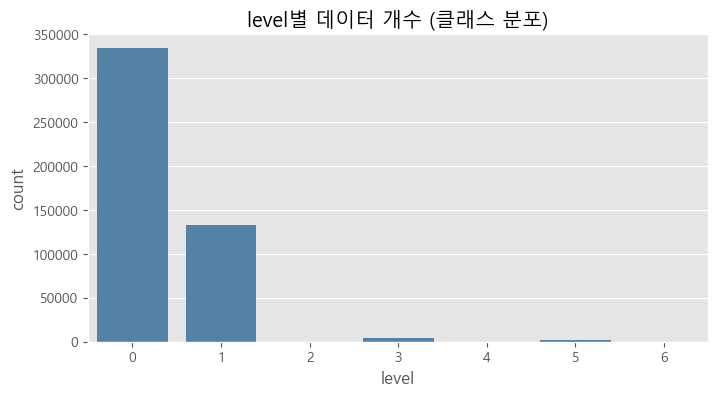

In [13]:
# 등급별 데이터 개수 막대그래프
plt.figure(figsize=(8, 4))
sns.barplot(x=level_counts.index, y=level_counts.values, color="steelblue")
plt.title("level별 데이터 개수 (클래스 분포)")
plt.xlabel("level")
plt.ylabel("count")
plt.show()

## 6. 데이터의 성격을 이해하기 위한 시각화

이 데이터는 단순한 숫자 데이터가 아니라, 여러 종류의 보안/시스템 로그가 섞여 있는 텍스트 데이터입니다.
이 섹션의 목적은 이 로그가 어떤 데이터인지 감을 잡는 것입니다.

> ⚠️ **중요:** 여기서 만드는 파생 컬럼(`log_length`, `log_source`, 키워드 포함 여부 등)은 데이터를 이해하기 위한 탐색(EDA)용입니다.
> baseline 모델에는 사용하지 않으며, 오직 `full_log` 의 TF-IDF feature만 사용합니다. (이 컬럼들을 모델에 넣어 보는 것은 이후 추가 실험에서 다룹니다.)

> **주의 — 패턴 매칭 금지 규정**
>
> 아래 분석 코드는 모델 예측에 사용하는 규칙이 아닙니다.
>
> 대회 규정상 특정 문자열이 있으면 특정 level로 직접 분류하는 패턴 매칭 방식은 사용할 수 없습니다.
>
> 아래 분석은 데이터를 이해하기 위한 EDA 목적입니다. 최종 모델 학습에는 키워드 기반 컬럼을 사용하지 않습니다.

> 키워드/출처/대표단어 분석은 기본적으로 train 데이터 기준으로 수행합니다.

### 6-1. 로그 길이 분석

`full_log` 의 글자 수(길이)를 살펴봅니다.

- 로그가 길수록 더 많은 정보가 담겨 있을 수 있습니다.
- 하지만 너무 긴 로그는 모델 학습을 무겁게 만들 수 있습니다.
- level에 따라 로그 길이 분포가 다르다면, 로그 길이도 분류에 도움이 될 수 있습니다.
- 이번 baseline에는 로그 길이를 feature로 넣지 않습니다. (→ 이후 추가 실험에서 다룹니다.)

In [14]:
# 로그 길이 컬럼 만들기 (탐색용)
train["log_length"] = train["full_log"].str.len()
test["log_length"] = test["full_log"].str.len()

print("[train 로그 길이 통계]")
print(train["log_length"].describe())

[train 로그 길이 통계]
count    472972.000000
mean        473.361624
std         317.267954
min           7.000000
25%         204.000000
50%         423.000000
75%         689.000000
max       64106.000000
Name: log_length, dtype: float64


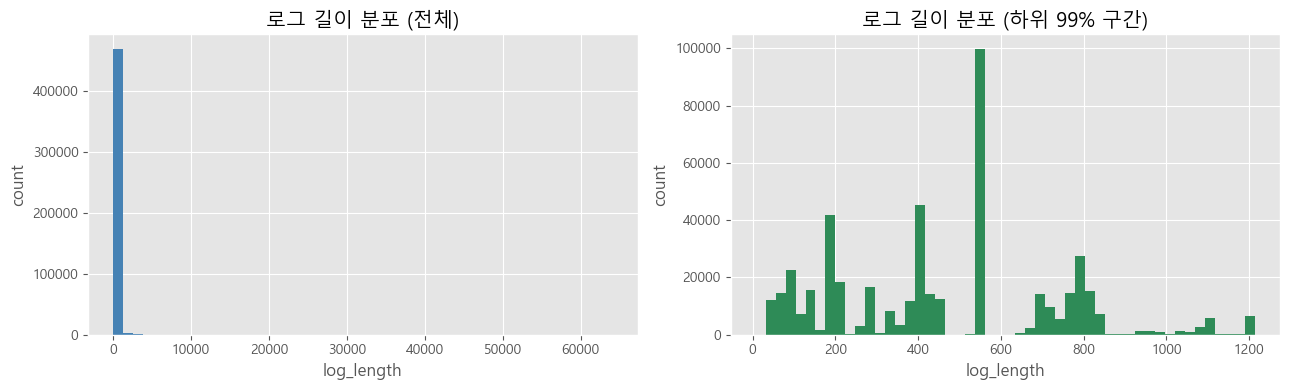

In [15]:
# 로그 길이 히스토그램 2개를 나란히 그립니다.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (왼쪽) 전체 로그 길이 분포
axes[0].hist(train["log_length"], bins=50, color="steelblue")
axes[0].set_title("로그 길이 분포 (전체)")
axes[0].set_xlabel("log_length")
axes[0].set_ylabel("count")

# (오른쪽) 너무 긴 일부 로그 때문에 그래프가 찌그러지므로 상위 99% 까지만 보기
upper = train["log_length"].quantile(0.99)
axes[1].hist(train.loc[train["log_length"] <= upper, "log_length"], bins=50, color="seagreen")
axes[1].set_title("로그 길이 분포 (하위 99% 구간)")
axes[1].set_xlabel("log_length")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

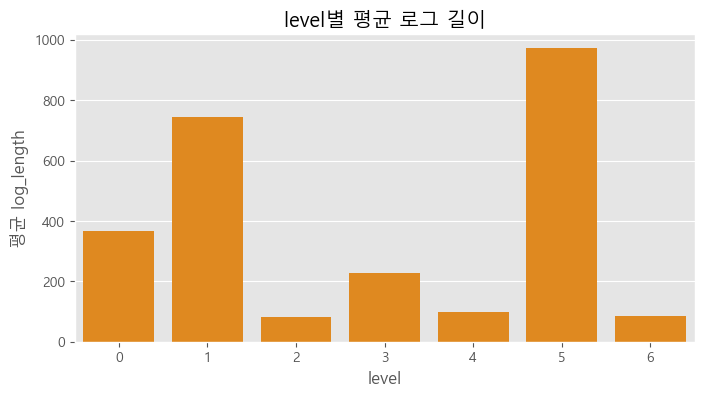

In [16]:
# level별 평균 로그 길이
mean_len_by_level = train.groupby("level")["log_length"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=mean_len_by_level.index, y=mean_len_by_level.values, color="darkorange")
plt.title("level별 평균 로그 길이")
plt.xlabel("level")
plt.ylabel("평균 log_length")
plt.show()

### 6-2. 로그 출처(서비스명) 추정

`full_log` 안의 키워드로 로그가 어디서 나온 것인지 대략 추정해 봅니다.

- 하나의 데이터셋 안에 여러 시스템 로그(kibana, sshd, audit 등)가 섞여 있을 수 있습니다.
- 로그 출처에 따라 자주 등장하는 단어/패턴이 다릅니다.
- 이 출처 추정은 정답 컬럼이 아니라, 로그를 이해하기 위한 단순 탐색용입니다.
- 키워드 기반의 단순 추정이며, 하나의 로그에 여러 키워드가 함께 나올 수 있으므로 완벽한 분류로 보면 안 됩니다.

> ⚠️ 아래 `detect_log_source` 함수는 EDA 전용입니다.
> 특정 키워드로 level을 직접 정하는 규칙 기반 예측이나 최종 모델 학습 feature로 사용하지 않습니다.

In [17]:
# 이 함수는 EDA 전용입니다.
# 특정 키워드가 있으면 특정 level로 직접 분류하는 규칙 기반 예측에 사용하지 않습니다.
# 최종 모델 학습 feature로도 사용하지 않으며, 오직 로그가 어디서 나왔는지 감을 잡는 용도입니다.
def detect_log_source(log):
    log_lower = str(log).lower()
    if "kibana" in log_lower:
        return "kibana"
    elif "logstash" in log_lower:
        return "logstash"
    elif "audit" in log_lower or "syscall" in log_lower:
        return "audit"
    elif "sshd" in log_lower:
        return "sshd"
    elif "ossec" in log_lower or "wazuh" in log_lower:
        return "ossec/wazuh"
    elif "systemd" in log_lower:
        return "systemd"
    elif "elasticsearch" in log_lower:
        return "elasticsearch"
    else:
        return "other"

# train 데이터에만 출처 추정 컬럼을 만듭니다. (탐색용이며 모델 학습에는 쓰지 않습니다.)
train["log_source"] = train["full_log"].apply(detect_log_source)

print("[추정된 로그 출처별 건수]")
print(train["log_source"].value_counts())

[추정된 로그 출처별 건수]
log_source
kibana           170248
logstash         138430
audit            118499
other             39041
sshd               2274
ossec/wazuh        2273
systemd            2198
elasticsearch         9
Name: count, dtype: int64


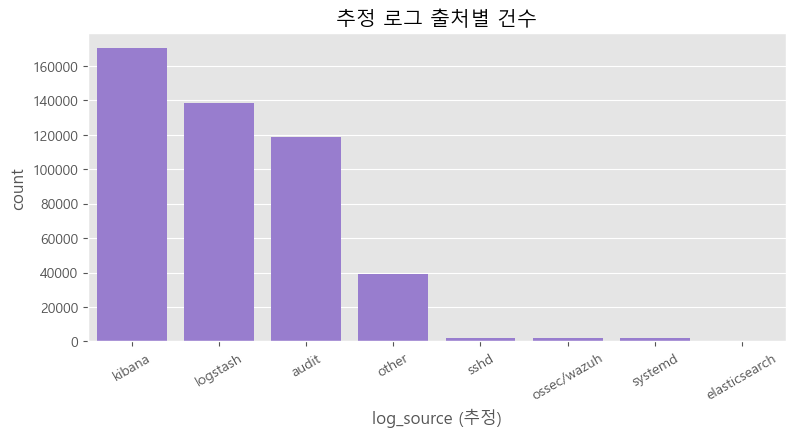

In [18]:
# 로그 출처별 건수 막대그래프
source_counts = train["log_source"].value_counts()

plt.figure(figsize=(9, 4))
sns.barplot(x=source_counts.index, y=source_counts.values, color="mediumpurple")
plt.title("추정 로그 출처별 건수")
plt.xlabel("log_source (추정)")
plt.ylabel("count")
plt.xticks(rotation=30)
plt.show()

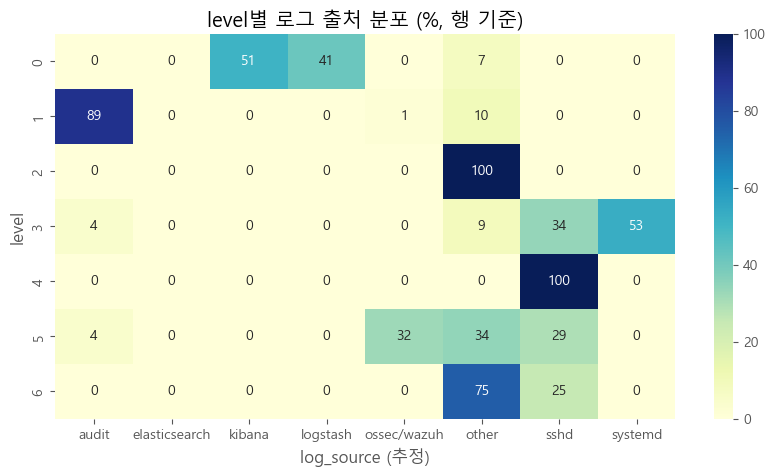

In [19]:
# level별 로그 출처 분포 (행: level, 열: 출처). 비율(%)로 보면 패턴이 잘 보입니다.
source_by_level = pd.crosstab(train["level"], train["log_source"], normalize="index") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(source_by_level, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("level별 로그 출처 분포 (%, 행 기준)")
plt.xlabel("log_source (추정)")
plt.ylabel("level")
plt.show()

### 6-3. 주요 보안 키워드 포함 여부 분석

보안 로그에서 자주 보이는 키워드가 로그에 들어 있는지 확인합니다.

- 키워드가 있다고 해서 반드시 공격 로그라는 뜻은 아닙니다. (예: `error` 는 단순 시스템 장애일 수도 있음)
- 키워드는 데이터를 이해하기 위한 단서일 뿐, 정답을 직접 의미하지 않습니다.

> ⚠️ 아래에서 만드는 `kw_*` 컬럼은 EDA 전용입니다.
> 특정 키워드 포함 여부로 level을 직접 분류하는 패턴 매칭에 사용하지 않으며, 최종 모델 학습 feature로도 사용하지 않습니다.

In [20]:
# 아래에서 만드는 kw_* 컬럼은 EDA 전용입니다.
# 특정 키워드 포함 여부로 level을 직접 정하는 규칙(패턴 매칭) 예측에 사용하지 않으며,
# 최종 모델 학습 feature로도 사용하지 않습니다.

# 확인할 주요 키워드 목록
keywords = [
    "error", "failed", "denied", "unauthorized", "attack", "malware", "root",
    "sudo", "sshd", "audit", "wazuh", "kibana", "logstash", "elasticsearch",
]

# 미리 소문자로 변환해두면 키워드 검색이 빠릅니다.
full_log_lower = train["full_log"].str.lower()

# 각 키워드 포함 여부(True/False) 컬럼을 만듭니다. (탐색용)
for kw in keywords:
    train["kw_" + kw] = full_log_lower.str.contains(kw, regex=False)

# 키워드별 포함 건수와 비율을 표로 정리합니다.
kw_summary = pd.DataFrame({
    "포함_건수": [train["kw_" + kw].sum() for kw in keywords],
    "포함_비율(%)": [round(train["kw_" + kw].mean() * 100, 2) for kw in keywords],
}, index=keywords).sort_values("포함_건수", ascending=False)

display(kw_summary)

,포함_건수,포함_비율(%)
error,293761,62.11
elasticsearch,196605,41.57
kibana,170248,36.00
logstash,138615,29.31
wazuh,120244,25.42
audit,118871,25.13
failed,63124,13.35
root,20680,4.37
sudo,14050,2.97
sshd,2941,0.62


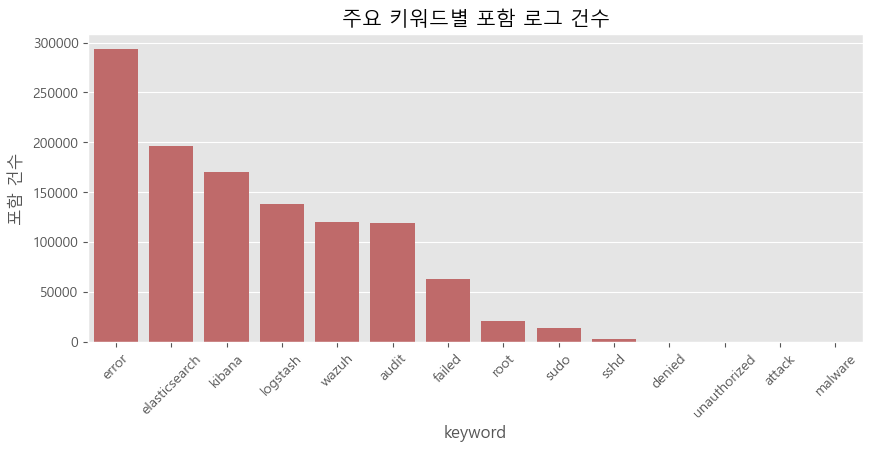

In [21]:
# 키워드별 포함 건수 막대그래프
plt.figure(figsize=(10, 4))
sns.barplot(x=kw_summary.index, y=kw_summary["포함_건수"].values, color="indianred")
plt.title("주요 키워드별 포함 로그 건수")
plt.xlabel("keyword")
plt.ylabel("포함 건수")
plt.xticks(rotation=45)
plt.show()

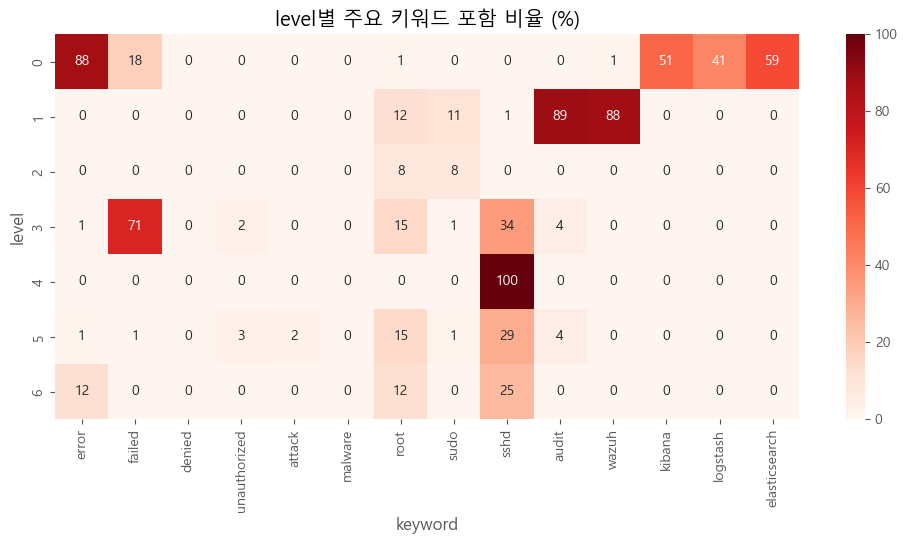

In [22]:
# level별 주요 키워드 포함 비율 heatmap (어떤 등급에 어떤 키워드가 자주 나오는지)
kw_cols = ["kw_" + kw for kw in keywords]
kw_ratio_by_level = train.groupby("level")[kw_cols].mean() * 100
kw_ratio_by_level.columns = keywords  # 보기 좋게 컬럼명 정리

plt.figure(figsize=(12, 5))
sns.heatmap(kw_ratio_by_level, annot=True, fmt=".0f", cmap="Reds")
plt.title("level별 주요 키워드 포함 비율 (%)")
plt.xlabel("keyword")
plt.ylabel("level")
plt.show()

### 6-4. level별 대표 단어 확인

각 등급에서 자주 등장하는 단어를 간단히 살펴봅니다. (복잡한 NLP 전처리는 하지 않습니다.)

- 소문자로 바꾸고, 알파벳/숫자/언더스코어 기준으로 단어를 잘라낸 뒤, 너무 짧은 단어는 제외합니다.
- **실행 안정성/속도를 위해 각 level당 최대 3000개 로그만 샘플링**해서 계산합니다. (희귀 level은 전체 사용)
- 이 분석은 **모델 학습용이 아니라 데이터 이해용**이므로 샘플링해도 괜찮습니다.

> 💡 TF-IDF는 이런 "단어 등장 패턴"을 더 체계적으로 숫자로 바꾸는 방법입니다.
> 단순히 자주 나오는 단어가 항상 중요한 단어는 아니므로, 단순 빈도보다 TF-IDF가 더 유용할 수 있습니다.

In [23]:
# 아래 단어 빈도 분석은 EDA(데이터 이해) 전용입니다.
# 특정 단어로 level을 직접 정하는 규칙 예측이나 모델 학습 feature로 사용하지 않습니다.

# 텍스트에서 자주 등장하는 상위 단어를 세는 간단한 함수
def get_top_words(texts, top_n=20):
    counter = Counter()
    for t in texts:
        # 소문자 변환 후 알파벳/숫자/언더스코어 단위로 단어 추출
        words = re.findall(r"[a-zA-Z0-9_]+", str(t).lower())
        # 너무 짧은 단어(2글자 이하)는 제외
        words = [w for w in words if len(w) >= 3]
        counter.update(words)
    return counter.most_common(top_n)

# level별 대표 단어 계산 (level당 최대 3000개 샘플)
# 실행 속도/안정성을 위해 샘플링하며, 데이터 이해용이므로 샘플링해도 괜찮습니다.
MAX_PER_LEVEL = 3000
top_words_by_level = {}
for lv in sorted(train["level"].unique()):
    logs = train.loc[train["level"] == lv, "full_log"]
    if len(logs) > MAX_PER_LEVEL:
        logs = logs.sample(MAX_PER_LEVEL, random_state=RANDOM_STATE)
    top_words_by_level[lv] = get_top_words(logs, top_n=20)

print("level별 대표 단어 계산 완료")

level별 대표 단어 계산 완료


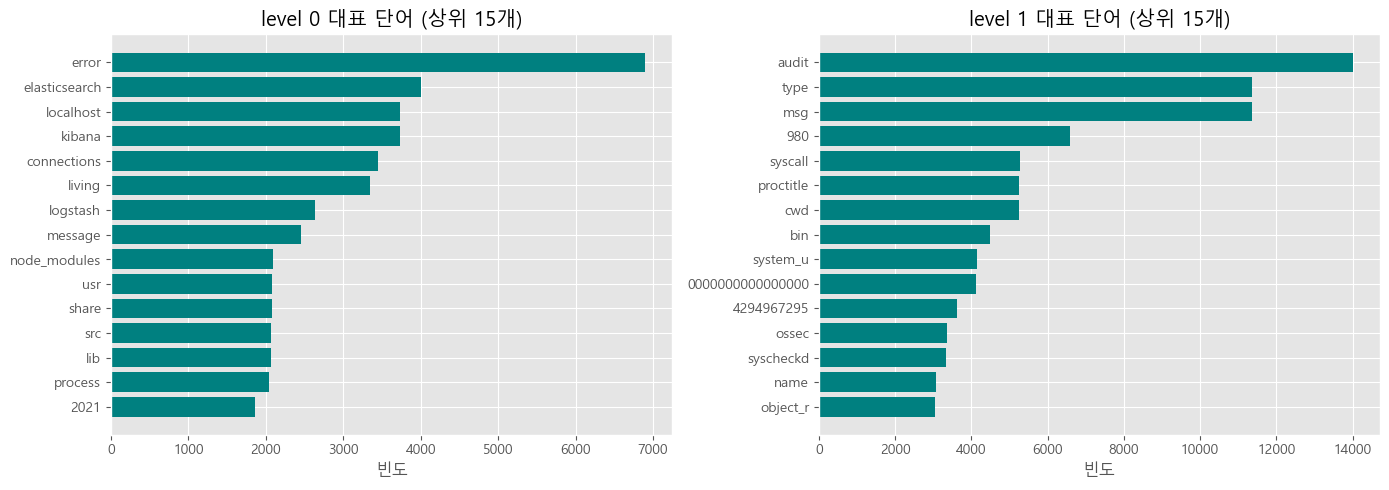

In [24]:
# 데이터가 많은 대표 level 2개만 막대그래프로 시각화 (그래프 수 절약)
top2_levels = train["level"].value_counts().head(2).index.tolist()
top2_levels = sorted(top2_levels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lv in zip(axes, top2_levels):
    words, counts = zip(*top_words_by_level[lv][:15])
    ax.barh(range(len(words)), counts, color="teal")
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()  # 가장 빈도 높은 단어가 위로 오게
    ax.set_title(f"level {lv} 대표 단어 (상위 15개)")
    ax.set_xlabel("빈도")
plt.tight_layout()
plt.show()

In [25]:
# 나머지 level은 표로 출력 (상위 10개 단어만)
print("[나머지 level의 대표 단어 (상위 10개)]")
for lv in sorted(train["level"].unique()):
    if lv in top2_levels:
        continue
    words = [w for w, c in top_words_by_level[lv][:10]]
    print(f"level {lv}: {words}")

[나머지 level의 대표 단어 (상위 10개)]
level 2: ['the', 'average', 'number', 'logs', 'between', 'and', 'reached', 'localhost', '5399', '37090']
level 3: ['localhost', 'jan', 'nist', 'failed', 'the', 'http', 'service', 'pdf', 'state', 'systemd']
level 4: ['sshd', 'did', 'not', 'receive', 'identification', 'string', 'from', 'nov', 'localhost', 'port']
level 5: ['tcp', '211', '253', '243', 'listen', 'udp', 'tcp6', 'tcp4', '127', '6000']
level 6: ['localhost', 'kernel', 'device', 'entered', 'promiscuous', 'mode', 'feb', 'jan', 'virbr0', 'nic']


### 6-5. level별 로그 예시 확인

숫자 level만 봐서는 의미를 알기 어렵습니다. 실제 로그 예시를 보면 각 등급이 어떤 유형의 로그와 연결되는지 감을 잡을 수 있습니다.

- 너무 긴 로그는 앞부분 500자만 보여줍니다.
- ⚠️ 정확한 level의 의미는 **대회/데이터 설명 문서**를 함께 확인해야 합니다.

In [26]:
# 각 level에서 로그 예시 1개씩 출력 (앞 500자만)
for lv in sorted(train["level"].unique()):
    example = train.loc[train["level"] == lv, "full_log"].iloc[0]
    print(f"===== level {lv} 예시 =====")
    print(str(example)[:500])
    print()

===== level 0 예시 =====
Sep 24 10:02:22 localhost kibana: {"type":"error","@timestamp":"2020-09-24T01:02:22Z","tags":["warning","stats-collection"],"pid":6458,"level":"error","error":{"message":"No Living connections","name":"Error","stack":"Error: No Living connections\n    at sendReqWithConnection (/usr/share/kibana/node_modules/elasticsearch/src/lib/transport.js:226:15)\n    at next (/usr/share/kibana/node_modules/elasticsearch/src/lib/connection_pool.js:214:7)\n    at process._tickCallback (internal/process/next_ti

===== level 1 예시 =====
type=SYSCALL msg=audit(1603094402.016:52981): arch=c000003e syscall=2 success=yes exit=3 a0=7ff220e805a4 a1=80000 a2=1 a3=7ff2210864f8 items=1 ppid=5877 pid=5878 auid=0 uid=0 gid=0 euid=0 suid=0 fsuid=0 egid=0 sgid=0 fsgid=0 tty=(none) ses=45 comm="date" exe="/usr/bin/date" subj=system_u:system_r:sysstat_t:s0-s0:c0.c1023 key="audit-wazuh-r" type=CWD msg=audit(1603094402.016:52981):  cwd="/root" type=PATH msg=audit(1603094402.016:52981): item=0 name

## 7. 문제 정의 (정리)

- 이 문제는 **다중분류(multiclass)** 문제입니다. (이진분류가 아닙니다.)
- `full_log` 는 문자열이라 모델이 바로 학습할 수 없습니다.
- 그래서 **TF-IDF** 로 문자열을 숫자 feature로 바꿉니다.
- 변환된 숫자 feature를 **XGBoost** 에 넣어 `level`(0~6)을 예측합니다.
- 이 baseline에서는 `log_length`, `log_source`, 키워드 포함 여부 등 **추가 feature는 모델에 넣지 않고**, 오직 `full_log` 의 TF-IDF feature만 사용합니다.
- 추가 feature 사용은 baseline 이후 추가 실험에서 다룹니다.

## 8. 모델 학습 데이터 준비

이 데이터는 level별 샘플 수가 매우 불균형합니다.

특히 일부 level은 전체 train 데이터에서도 샘플 수가 매우 적습니다.
따라서 빠른 실행을 위해 일부 행만 샘플링하면 희귀 level이 사라지거나, train/validation 분리 과정에서 오류가 발생할 수 있습니다.

이 baseline 노트북에서는 안정적인 실행과 교육 흐름을 위해 **전체 train 데이터를 사용**합니다.

`train_model` 은 이후 모델 학습에 사용할 데이터를 의미합니다.
현재 baseline에서는 샘플링하지 않으므로 `train` 전체를 그대로 복사합니다.

이렇게 변수명을 분리하면 나중에 학생들이 전처리나 실험을 추가할 때 원본 `train` 을 보존할 수 있습니다.

실행 시간이 오래 걸릴 경우에는 데이터를 샘플링하기보다 TF-IDF의 `max_features`, XGBoost의 `n_estimators`, `max_depth` 등을 줄여서 실험합니다.

In [ ]:
# ============================================================
# 모델 학습에 사용할 데이터 준비
# ============================================================

# 이 baseline에서는 전체 train 데이터를 사용합니다.
# 클래스 불균형이 매우 심한 데이터이므로,
# 일부 샘플만 뽑으면 희귀 클래스가 사라지거나
# train/validation 분리 과정에서 오류가 발생할 수 있습니다.
#
# 따라서 교육용 baseline에서는 샘플링하지 않고 전체 train을 사용합니다.

train_model = train.copy()

print("모델 학습에 사용할 
 크기:", train_model.shape)

print("\n[train_model level 분포]")
print(train_model["level"].value_counts().sort_index())

모델 학습에 사용할 train_model 크기: (472972, 19)

[train_model level 분포]
level
0    334065
1    132517
2        12
3      4141
4        10
5      2219
6         8
Name: count, dtype: int64


## 9. 학습/검증 데이터 분리

모델이 처음 보는 데이터에서도 잘 작동하는지 확인하기 위해, 학습용(train)과 검증용(validation)으로 나눕니다.

- 전체 train 데이터를 사용하므로 희귀 클래스도 최대한 보존됩니다.
- `test_size=0.2` : 20%를 검증용으로 떼어 둡니다.
- `stratify=y` : **나누기 전후의 level 분포(비율)를 비슷하게 유지**합니다.
  - 클래스 불균형 데이터에서는 train/validation 분리 시 `stratify` 를 사용하는 것이 중요합니다.
  - 이 옵션을 쓰지 않으면 희귀한 등급이 한쪽에만 몰려 검증 점수를 믿기 어려워질 수 있습니다.

In [40]:
# 입력(X)과 정답(y)을 정의합니다. baseline은 오직 full_log 텍스트만 입력으로 사용합니다.
X = train_model["full_log"]
y = train_model["level"]

# 학습용(train)과 검증용(valid)으로 나눕니다.
# - test_size=0.2: 전체의 20%를 검증용으로 떼어 둡니다. (모델이 보지 않은 데이터로 성능 확인)
# - stratify=y: 분리 전후의 level 비율을 비슷하게 유지합니다.
#   클래스 불균형이 심한 데이터에서 stratify를 쓰지 않으면, 희귀 level이 한쪽에만 몰려
#   검증 점수를 신뢰하기 어려워질 수 있습니다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print()
print("[검증 데이터 level 분포]")
print(y_valid.value_counts().sort_index())

X_train: (378377,)
X_valid: (94595,)

[검증 데이터 level 분포]
level
0    66813
1    26504
2        2
3      828
4        2
5      444
6        2
Name: count, dtype: int64


## 10. TF-IDF 벡터화

텍스트(`full_log`)를 숫자로 바꿉니다. TF-IDF는 "자주 나오면서 특정 문서에서 특징적인 단어"에 높은 점수를 줍니다.

꼭 지켜야 할 규칙:

- **학습 데이터**에만 `fit_transform` 을 사용합니다. (단어 사전을 학습 데이터로 만듦)
- **검증 데이터/테스트 데이터**에는 `transform` 만 사용합니다.
- 검증/테스트에 `fit_transform` 을 쓰면 안 됩니다. → 그러면 "정답을 미리 본 것"처럼 되어(데이터 누수, data leakage) 점수를 신뢰할 수 없게 됩니다.

메모리 주의:

- TF-IDF 결과는 **희소 행렬(sparse matrix)** 입니다. (대부분이 0이라 메모리를 적게 씀)
- `.toarray()` 로 일반 배열로 바꾸거나, pandas DataFrame으로 바꾸지 **마세요.** 데이터가 커서 메모리가 터질 수 있습니다.
- XGBoost에는 **희소 행렬 그대로** 넣습니다.

In [41]:
# baseline TF-IDF 설정 (너무 무겁지 않게 단어 수를 제한합니다)
tfidf = TfidfVectorizer(
    max_features=5000,     # 사용할 단어(feature) 개수를 5000개로 제한 (baseline 기준)
    ngram_range=(1, 2),    # 단어 1개(unigram) + 2개 묶음(bigram)까지 사용
    min_df=3,              # 너무 드문 단어(3개 미만 문서에만 등장)는 제외
    max_df=0.95,           # 너무 흔한 단어(95% 이상 문서에 등장)는 제외
)

# 학습 데이터에는 fit_transform을 사용합니다.
# fit 단계에서 단어 사전을 만들고, transform 단계에서 각 로그를 숫자 feature로 변환합니다.
X_train_tfidf = tfidf.fit_transform(X_train)

# 검증 데이터에는 transform만 사용합니다.
# 검증 데이터로 단어 사전을 새로 만들면(fit) 학습/평가 기준이 달라지고,
# 정답을 미리 본 것과 같은 데이터 누수(data leakage)가 생기므로 fit을 다시 하지 않습니다.
X_valid_tfidf = tfidf.transform(X_valid)

X_train_tfidf = X_train_tfidf.astype('float32')
X_valid_tfidf = X_valid_tfidf.astype('float32')

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
# TF-IDF 결과는 대부분이 0인 희소 행렬(sparse matrix)입니다.
# .toarray()로 바꾸면 메모리가 크게 늘어날 수 있으므로, 희소 행렬 그대로 모델에 넣습니다.
print("희소 행렬 형태인가? ", sparse.issparse(X_train_tfidf))

X_train_tfidf shape: (378377, 5000)
X_valid_tfidf shape: (94595, 5000)
희소 행렬 형태인가?  True


## 11. XGBoost 다중분류 baseline 모델 학습

이 노트북에서는 모델로 XGBoost를 사용합니다.

이번 실습의 핵심은 XGBoost의 내부 수식을 자세히 다루는 것이 아니라, 다음 흐름을 직접 확인하는 것입니다.

1. 로그 텍스트를 숫자 feature로 변환하기
2. 다중분류 모델 학습하기
3. Macro F1로 평가하기
4. 제출 파일 만들기

주요 설정:

- `objective="multi:softprob"` : 다중분류 설정 (각 클래스 확률을 출력)
- `num_class` : 클래스(등급) 개수
- `level` 은 이미 0부터 시작하는 정수 라벨이므로 **`LabelEncoder` 를 쓰지 않고** 그대로 사용합니다.

**클래스 개수(`num_classes`)는 전체 train 기준으로 계산합니다.**

- 클래스 개수는 일부 데이터가 아니라 **전체 `train` 기준**으로 확인하는 것이 가장 안전합니다.
- 이 baseline에서는 `train_model` 이 곧 `train` 전체이지만, 이후 전처리나 실험을 추가하더라도 클래스 개수만큼은 전체 `train` 기준으로 확인합니다.

**`level 7` 에 대한 주의 (매우 중요):**

- XGBoost 모델은 train 데이터에 존재하는 **`0~6` 클래스만 학습**합니다.
- `level 7` 은 모델이 학습하는 클래스가 **아닙니다.** 뒤의 "선택 실험"에서 다루는, 예측 확률이 낮은 샘플을 사후적으로 바꾸는 **제출 후처리 값**일 뿐입니다.
- 따라서 `num_class` 는 train 라벨 기준인 **7개로 유지**하며, `level 7` 을 포함한다고 해서 `num_class=8` 로 바꾸지 **않습니다.**

> baseline에는 복잡한 튜닝(early stopping, Optuna, GridSearchCV 등)을 넣지 않습니다. 이런 항목은 baseline 이후 추가 실험에서 다룹니다.

In [42]:
# 클래스(등급) 개수는 전체 train 기준으로 계산합니다.
# 전체 train으로 확인하면, 나중에 일부 데이터로 실험하더라도 클래스 개수가 안전하게 유지됩니다.
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("전체 train 기준 라벨 목록:", labels_sorted)
print("전체 train 기준 클래스 개수:", num_classes)

# XGBoost 다중분류 baseline 모델을 정의합니다.
# 주의: num_class 는 train 라벨(0~6) 기준인 7개입니다.
#       level 7은 학습 클래스가 아니라 뒤의 선택 실험에서 다루는 후처리 값이므로 8로 바꾸지 않습니다.
model = XGBClassifier(
    n_estimators=100,            # 생성할 트리 개수
    max_depth=4,                 # 각 트리의 최대 깊이
    learning_rate=0.1,           # 각 트리의 반영 정도(학습률)
    subsample=0.8,               # 각 트리 학습에 사용할 행(샘플) 비율
    colsample_bytree=0.8,        # 각 트리 학습에 사용할 feature(컬럼) 비율
    objective="multi:softprob",  # 다중분류: 각 클래스에 대한 확률을 예측
    num_class=num_classes,       # 학습 데이터에 존재하는 클래스 개수 (전체 train 기준 = 7)
    eval_metric="mlogloss",      # 다중분류 학습 과정에서 사용할 평가 지표
    random_state=RANDOM_STATE,
    tree_method="hist",         # GPU 가속을 위한 트리 빌드 방법
    device="cuda",              # RTX A4000 GPU 지정을 위한 설정
    # n_jobs=-1,                   # 모든 CPU 코어 사용
)

# 희소 행렬을 그대로 입력해 학습합니다.
model.fit(X_train_tfidf, y_train)
print("모델 학습 완료")

전체 train 기준 라벨 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
전체 train 기준 클래스 개수: 7
모델 학습 완료


## 12. 검증 데이터 평가

검증 데이터로 모델 성능을 확인합니다. 지표를 해석하는 방법:

- **accuracy** : 전체 정답률.
- **precision(정밀도)** : 어떤 level이라고 **예측한 것 중** 실제로 맞은 비율.
- **recall(재현율)** : 실제 그 level인 것 중 모델이 **맞힌** 비율.
- **f1-score** : precision과 recall의 균형(조화평균).
- **support** : 해당 level의 실제 데이터 개수.
- **macro avg** : 각 클래스를 **똑같은 비중**으로 평균 → 불균형에서 중요.
- **weighted avg** : 데이터 많은 클래스에 **더 큰 비중**을 둔 평균.

### 왜 Macro F1을 확인할까?

이 데이터는 level별 데이터 개수가 균등하지 않습니다.

많이 등장하는 level을 잘 맞히면 accuracy는 높아 보일 수 있습니다.
하지만 적게 등장하는 level을 거의 맞히지 못할 수도 있습니다.

Macro F1은 각 level의 F1-score를 따로 계산한 뒤 평균을 냅니다.
따라서 각 level의 성능을 함께 확인할 수 있습니다.

이 대회에서는 accuracy뿐 아니라 Macro F1을 함께 확인해야 합니다.

---

`labels=labels_sorted` 를 지정하면 평가 보고서가 항상 전체 학습 라벨인 level 0~6 기준으로 출력됩니다.

이 데이터는 클래스 불균형이 매우 심하므로, 특정 level을 모델이 거의 예측하지 못할 수 있습니다.
따라서 accuracy만 보지 말고 macro F1, level별 recall, support를 함께 확인합니다.

> 데이콘 대회에 별도 평가 지표가 있다면 **그 지표를 우선** 확인합니다.

In [43]:
# 검증 데이터에 대해 예측을 수행합니다. (학습에 사용하지 않은 데이터로 성능을 확인)
valid_pred = model.predict(X_valid_tfidf)

# 평가 보고서에 사용할 라벨 이름 (level 0~6)
# labels_sorted 는 전체 train 기준으로 이미 계산된 라벨 목록입니다.
target_names = [f"level {label}" for label in labels_sorted]

# accuracy: 전체 정답률. 다수 클래스만 잘 맞혀도 높게 나올 수 있어 단독으로 보면 안 됩니다.
accuracy = accuracy_score(y_valid, valid_pred)

# macro F1: 각 level의 F1을 따로 구한 뒤 같은 비중으로 평균합니다.
# 클래스가 불균형한 데이터에서 희귀 level의 성능까지 함께 반영하므로 중요한 지표입니다.
macro_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="macro",
    zero_division=0,
)

# weighted F1: 데이터가 많은 클래스에 더 큰 비중을 둔 평균입니다. (macro F1과 함께 비교)
weighted_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="weighted",
    zero_division=0,
)

print("Accuracy   :", round(accuracy, 4))
print("Macro F1   :", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print()

# class별 상세 지표(precision/recall/f1/support)를 한 번에 확인합니다.
# labels=labels_sorted: 예측이 한 번도 없는 level도 보고서에서 빠지지 않게 고정합니다.
# zero_division=0: 예측이 없는 클래스 때문에 경고/에러가 나지 않게 합니다.
# support가 작은 level의 recall이 낮다면, 모델이 희귀 등급을 잘 못 맞히고 있다는 신호입니다.
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )
)

Accuracy   : 0.998
Macro F1   : 0.8044
Weighted F1: 0.998

              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       0.00      0.00      0.00         2
     level 5       1.00      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       0.86      0.78      0.80     94595
weighted avg       1.00      1.00      1.00     94595



## 13. Confusion Matrix(혼동 행렬) 시각화

어떤 등급을 어떤 등급으로 헷갈렸는지 한눈에 봅니다.

- 행(y축): 실제 정답(True Label)
- 열(x축): 모델 예측(Predicted Label)
- 대각선(왼쪽 위 → 오른쪽 아래)이 진할수록 잘 맞힌 것입니다.

confusion matrix도 `labels_sorted` 기준으로 고정하면, 예측되지 않은 level이 있더라도 축에서 빠지지 않습니다.
그래야 희귀 level을 모델이 얼마나 못 맞히는지 확인할 수 있습니다.

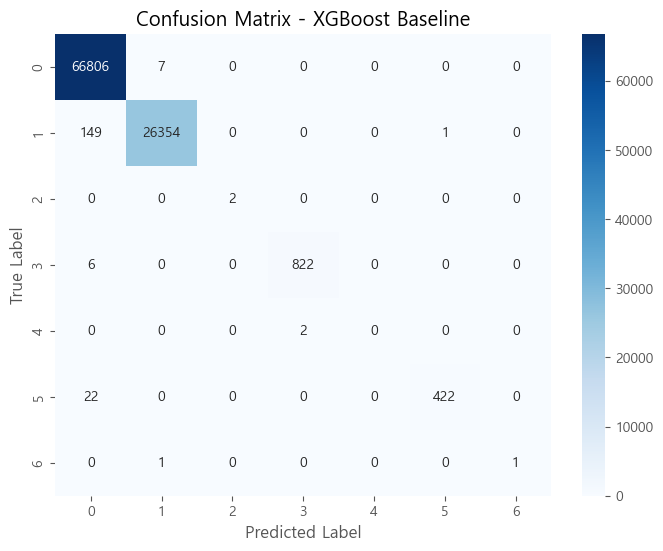

In [44]:
# 혼동 행렬을 계산합니다. labels로 라벨 순서를 0~6으로 고정합니다.
# 라벨을 고정하면 예측이 한 번도 안 된 level이 있어도 축에서 빠지지 않아,
# 희귀 level을 모델이 얼마나 못 맞히는지 그대로 확인할 수 있습니다.
labels_sorted = sorted(train["level"].unique())
cm = confusion_matrix(y_valid, valid_pred, labels=labels_sorted)

# 행(y축)=실제 정답, 열(x축)=모델 예측. 대각선이 진할수록 잘 맞힌 것입니다.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 14. 전체(train_model) 데이터로 최종 모델 학습

지금까지는 검증을 위해 데이터의 80%만 학습에 썼습니다.
제출용 모델은 **가지고 있는 학습 데이터를 모두 사용**해 다시 학습하는 것이 일반적으로 더 좋습니다.

절차:

1. `train_model` 전체의 `full_log` 로 TF-IDF를 다시 `fit`
2. 같은 데이터로 XGBoost 모델 다시 학습
3. test의 `full_log` 를 `transform` (절대 `fit_transform` 아님!)
4. test 예측

> 제출용 test에는 정답 `level` 이 없으므로 평가하지 않습니다.
> `level` 은 이미 제출 가능한 정수 라벨이라 inverse_transform 같은 복원도 필요 없습니다.

In [57]:
# 검증 단계에서는 데이터의 80%만 학습에 사용했습니다.
# 제출용 모델은 가지고 있는 학습 데이터를 모두 사용해 다시 학습하는 것이 일반적으로 더 좋습니다.

# 1) 최종 학습에 사용할 전체 입력/정답 (train_model 전체)
X_all = train_model["full_log"]
y_all = train_model["level"]

# 2) TF-IDF를 전체 학습 데이터로 다시 fit 합니다. (검증 때와 동일한 설정)
final_tfidf = TfidfVectorizer(
    max_features=5000,     # 사용할 단어(feature) 개수를 5000개로 제한 (baseline 기준)
    ngram_range=(1, 2),    # 단어 1개(unigram) + 2개 묶음(bigram)까지 사용
    min_df=3,              # 너무 드문 단어(3개 미만 문서에만 등장)는 제외
    max_df=0.95, 
)
# 학습 데이터는 fit_transform으로 단어 사전을 만들며 변환합니다.
X_all_tfidf = final_tfidf.fit_transform(X_all)
# 테스트 데이터는 transform만 사용합니다. fit_transform을 쓰면 데이터 누수가 되므로 주의합니다.
X_test_tfidf = final_tfidf.transform(test["full_log"])

X_all_tfidf = X_all_tfidf.astype('float32')
X_test_tfidf = X_test_tfidf.astype('float32')

print("X_all_tfidf  shape:", X_all_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_all_tfidf  shape: (472972, 50000)
X_test_tfidf shape: (1418916, 50000)


In [58]:
# 3) 최종 XGBoost 모델을 전체 학습 데이터로 학습합니다. (검증 때와 동일한 설정)
final_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    tree_method="hist",         # GPU 가속을 위한 트리 빌드 방법
    device="cuda",              # RTX A4000 GPU 지정을 위한 설정
    # n_jobs=-1,
)
final_model.fit(X_all_tfidf, y_all)

# 4) 테스트 데이터를 예측합니다.
#    predict는 각 샘플에 대해 가장 확률이 높은 클래스(level 0~6 중 하나)를 바로 돌려줍니다.
#    (각 클래스의 확률값 자체가 필요할 때는 뒤의 선택 실험에서 predict_proba를 사용합니다.)
#    이 기본 예측값은 test_pred_basic 으로 따로 두어, 뒤의 선택 실험 결과와 구분합니다.
test_pred_basic = final_model.predict(X_test_tfidf)
print("최종 모델 학습 및 test 예측 완료")
print("예측 결과 개수:", len(test_pred_basic))
print("예측된 level 분포:", pd.Series(test_pred_basic).value_counts().sort_index().to_dict())

최종 모델 학습 및 test 예측 완료
예측 결과 개수: 1418916
예측된 level 분포: {0: 1003925, 1: 395525, 2: 34, 3: 12964, 4: 34, 5: 6411, 6: 23}


## 15. 선택 실험: 모델이 확신하지 못하는 로그 처리하기

> ℹ️ 이 섹션은 기본 baseline이 아니라 **선택 실험**입니다. 실행해도 기본 제출값(`test_pred_basic`)은 그대로 유지되며, 원할 때만 후처리 결과를 제출값으로 바꿀 수 있습니다.

이 대회에서는 학습 데이터에 `level 0~6`만 존재하지만, 제출 결과에는 `level 7`도 포함될 수 있습니다.

일반적인 지도학습 모델은 학습 데이터에 없던 `level 7`을 직접 학습하기 어렵습니다.
따라서 이 노트북에서는 먼저 `level 0~6`을 예측하는 기본 모델을 만들고, 추가 실험으로 모델의 예측 확률이 낮은 샘플을 어떻게 처리할지 살펴봅니다.

이 실험의 목적은 점수를 무조건 올리는 방법을 외우는 것이 아닙니다.
학습 데이터에 없는 새로운 유형을 모델이 어떻게 다룰 수 있는지 생각해 보는 것입니다.

**모델 구조와의 관계:**

- XGBoost 모델은 train 데이터에 존재하는 `0~6` 클래스만 학습합니다.
- `level 7` 은 모델이 학습한 클래스가 아니라, 예측 확률이 낮을 때 사후적으로 바꾸는 **선택적 제출 후처리 값**입니다.
- 따라서 XGBoost의 `num_class` 는 **7개**이며, `level 7` 을 포함해 `num_class=8` 로 설정하지 **않습니다.**

**threshold(임계값) 이해:**

threshold는 모델이 얼마나 확신해야 기존 예측을 유지할지 정하는 기준입니다.

예를 들어 threshold가 0.7이면, 모델의 최대 예측 확률이 0.7보다 낮은 샘플을 모델이 충분히 확신하지 못한 샘플로 볼 수 있습니다.

threshold가 높을수록 더 많은 샘플이 level 7로 바뀝니다.
따라서 threshold를 높인다고 항상 좋은 것은 아닙니다.

- `THRESHOLD = 0.5` 는 정답값이 아니라 **실험 시작값**입니다.
- threshold는 validation 결과와 데이콘 public score를 **함께 보면서** 실험합니다.
- 다만 validation 데이터에는 정답 `level 7` 이 없을 수 있으므로, 후처리를 **validation macro F1만으로 평가하면 불리하게 보일 수 있습니다.**
- 따라서 threshold 실험은 **validation 예측 분포**와 **데이콘 제출 점수**를 함께 확인합니다.

In [59]:
# ============================================================
# 선택 실험: 예측 확률이 낮은 샘플을 level 7로 변경하기
# 이 셀은 기본 학습이 아니라 선택 후처리 실험입니다. 기본 제출과 구분합니다.
# ============================================================

# predict_proba는 각 샘플이 클래스(0~6)에 속할 예측 확률을 모두 돌려줍니다.
# (predict는 이 중 가장 큰 확률의 클래스 하나만 돌려줍니다.)
test_proba = final_model.predict_proba(X_test_tfidf)

# 각 샘플에서 가장 높은 클래스 확률을 구합니다.
# 이 값은 모델이 자신의 예측을 얼마나 확신하는지 확인하는 데 사용합니다.
max_proba = np.max(test_proba, axis=1)

# THRESHOLD: 기존 예측을 유지할 최소 확신 기준입니다.
# 최대 예측 확률이 이 값보다 낮은 샘플은 모델이 충분히 확신하지 못한 것으로 보고 level 7로 바꿉니다.
# 주의: 0.5는 정답값이 아니라 실험 시작값입니다. (threshold 값에 따라 결과가 달라집니다.)
THRESHOLD = 0.5

# 기본 예측을 복사한 뒤, 확신도가 낮은 샘플만 level 7로 바꿉니다. (기본 예측값은 그대로 보존)
test_pred_with_7 = test_pred_basic.copy()
test_pred_with_7[max_proba < THRESHOLD] = 7

print("[기본 예측 분포]")
print(pd.Series(test_pred_basic).value_counts().sort_index())

print("\n[level 7 후처리 적용 후 예측 분포]")
print(pd.Series(test_pred_with_7).value_counts().sort_index())

print("\nlevel 7로 변경된 개수:", (test_pred_with_7 == 7).sum())
print("전체 test 개수:", len(test_pred_with_7))
print("level 7 비율:", (test_pred_with_7 == 7).mean())

[기본 예측 분포]
0    1003925
1     395525
2         34
3      12964
4         34
5       6411
6         23
Name: count, dtype: int64

[level 7 후처리 적용 후 예측 분포]
0    1003809
1     395442
2         34
3      12959
4         34
5       6401
6         23
7        214
Name: count, dtype: int64

level 7로 변경된 개수: 214
전체 test 개수: 1418916
level 7 비율: 0.0001508193578760124


### 15-1. threshold 값에 따른 level 7 예측 개수 비교

threshold가 커질수록 모델이 "확신이 낮다"고 판단하는 범위가 넓어지므로, level 7로 바뀌는 예측 개수가 늘어날 수 있습니다.

이 표는 threshold 선택을 돕기 위한 참고용입니다.
이 표만으로 어떤 threshold가 좋은지 결정할 수는 없으며, 실제 데이콘 public score와 함께 비교해야 합니다.

> ⚠️ 이 표는 test 정답이 없으므로 **성능을 평가하는 표가 아닙니다.** 단순히 threshold에 따라 level 7 제출 개수가 어떻게 변하는지 보여주는 탐색 표입니다.

In [60]:
# ============================================================
# threshold 값에 따른 level 7 예측 개수 비교
# ============================================================

threshold_list = [0.5, 0.6, 0.7, 0.8, 0.9]

threshold_summary = []

for threshold in threshold_list:
    temp_pred = test_pred_basic.copy()
    temp_pred[max_proba < threshold] = 7

    threshold_summary.append({
        "threshold": threshold,
        "level_7_count": int((temp_pred == 7).sum()),
        "level_7_ratio": float((temp_pred == 7).mean()),
    })

threshold_summary = pd.DataFrame(threshold_summary)

display(threshold_summary)

,threshold,level_7_count,level_7_ratio
0,0.5,214,0.000151
1,0.6,1299,0.000915
2,0.7,5237,0.003691
3,0.8,7132,0.005026
4,0.9,7540,0.005314


## 16. 제출에 사용할 예측값 선택

위에서 만든 두 가지 예측값(`test_pred_basic`, `test_pred_with_7`) 중 **어떤 것을 제출에 쓸지** 여기서 명확히 선택합니다.

- 처음 제출은 **기본 baseline 예측값(`test_pred_basic`)** 으로 합니다.
- 이후 threshold 실험을 하고 싶으면 아래 셀에서 `test_pred_with_7` 을 제출값으로 바꿉니다.
- 여러 threshold를 비교할 때는 위 "선택 실험" 셀의 `THRESHOLD` 값을 바꿔가며 제출 파일을 만들어 데이콘 점수를 비교합니다.
- 최종 submission 생성 셀에서는 **반드시 `test_pred_for_submission`** 만 사용합니다. (`test_pred` 같은 모호한 변수는 쓰지 않습니다.)

In [61]:
# ============================================================
# 제출에 사용할 예측값 선택
# ============================================================

# 기본 baseline 제출값: level 0~6만 예측
test_pred_for_submission = test_pred_basic

# level 7 후처리를 적용하고 싶으면 아래 줄의 주석을 해제하고,
# 위 줄을 주석 처리하세요.
# test_pred_for_submission = test_pred_with_7

print("최종 제출에 사용할 예측값 분포:")
print(pd.Series(test_pred_for_submission).value_counts().sort_index())

최종 제출에 사용할 예측값 분포:
0    1003925
1     395525
2         34
3      12964
4         34
5       6411
6         23
Name: count, dtype: int64


## 17. 데이콘 test 예측 및 submission.csv 생성

`sample_submission.csv` 를 복사한 뒤, 예측값 컬럼만 우리 예측(`test_pred_for_submission`)으로 바꿔서 저장합니다.

제출 전에 확인할 점:

- 데이콘 제출에서는 `sample_submission.csv` 의 **형식을 그대로 맞춰야** 합니다. (같은 행 개수, 같은 컬럼)
- 보통 **마지막 컬럼**에 예측값을 넣지만, 대회마다 다를 수 있으므로 **컬럼명을 직접 확인**합니다.
- `sample_submission` 만으로는 모든 허용 label을 알 수 없습니다. **허용 label 범위는 대회 설명을 확인**합니다.
- 저장 전에 **예측값 분포**를 확인하면, 특정 클래스만 과도하게 예측되는 문제를 미리 발견할 수 있습니다.
- 저장된 CSV 파일을 데이콘 제출 페이지에 업로드합니다.

In [62]:
# sample_submission을 복사해서 제출 형식(행 개수, 컬럼)을 그대로 유지합니다.
submission = sample_submission.copy()

# sample_submission 의 컬럼 구조를 먼저 확인합니다.
print("sample_submission 컬럼:", sample_submission.columns.tolist())

# 일반적으로 sample_submission의 "마지막 컬럼"이 예측값을 넣는 컬럼입니다.
# 이 대회의 sample_submission은 ['id', 'level'] 구조라서 마지막 컬럼이 'level'입니다.
# columns[-1] 방식은 컬럼명이 달라도 동작하도록 일반화한 것이며, 대회마다 컬럼명을 직접 확인합니다.
target_col = submission.columns[-1]
print("예측값을 넣을 컬럼:", target_col)

# sample_submission의 마지막 컬럼에 어떤 값들이 들어있는지 예시로 확인합니다.
# (단, sample_submission만으로 모든 허용 label을 알 수는 없습니다. 대회 설명을 확인하세요.)
print("sample_submission 마지막 컬럼 고유값 예시:")
print(sample_submission[target_col].unique()[:20])

# 행 개수가 test 데이터와 같은지 확인합니다. (제출 파일은 test와 행 개수가 같아야 합니다.)
print("test 행 개수:", len(test))
print("submission 행 개수:", len(submission))

# 예측 결과를 제출 파일의 예측 컬럼(level)에 저장합니다. (반드시 test_pred_for_submission 사용)
submission[target_col] = test_pred_for_submission

# 안전 확인: 제출 파일과 test의 행 개수가 같아야 합니다.
assert len(submission) == len(test), "submission과 test의 행 개수가 다릅니다."

# 제출 예측값 분포 확인 (특정 클래스만 과도하게 예측되는지 점검)
print("\n제출 예측값 분포:")
print(submission[target_col].value_counts().sort_index())

# 저장 (한글/엑셀 호환을 위해 utf-8-sig)
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

# 저장된 CSV 파일을 데이콘 제출 페이지에 업로드하면 됩니다.
print(f"\n제출 파일이 저장되었습니다: {OUTPUT_PATH}")
display(submission.head())

sample_submission 컬럼: ['id', 'level']
예측값을 넣을 컬럼: level
sample_submission 마지막 컬럼 고유값 예시:
[0]
test 행 개수: 1418916
submission 행 개수: 1418916

제출 예측값 분포:
level
0    1003925
1     395525
2         34
3      12964
4         34
5       6411
6         23
Name: count, dtype: int64

제출 파일이 저장되었습니다: submission.csv


,id,level
0,1000000,0
1,1000001,0
2,1000002,1
3,1000003,0
4,1000004,1


### 17-1. 제출 파일명 관리 팁

기본 제출 파일명은 `submission.csv` 입니다.

threshold 실험을 여러 번 수행하면 파일이 계속 덮어써질 수 있습니다.
여러 실험 결과를 비교하려면 위쪽 설정 셀의 `OUTPUT_PATH` 를 다음처럼 바꾸어 저장할 수 있습니다.

```python
OUTPUT_PATH = "submission_threshold_05.csv"
OUTPUT_PATH = "submission_threshold_07.csv"
OUTPUT_PATH = "submission_xgboost_baseline.csv"
```

제출 파일명을 바꿀 때는 **어떤 설정으로 만든 파일인지** 노트에 함께 기록하는 것이 좋습니다.

> 기본값은 `OUTPUT_PATH = "submission.csv"` 그대로 유지하면 됩니다. 위 예시는 실험 파일을 따로 보관하고 싶을 때만 사용합니다.

## 18. baseline 이후 추가 실험

이 baseline을 출발점으로 삼아, 아래 항목들을 직접 실험하며 결과를 비교해 보세요. 실험은 **필수 → 선택 → 확장** 순서로 난이도가 올라갑니다.

각 실험에서 공통으로 확인할 점:

- accuracy만 보지 말고 **macro F1과 level별 recall**을 함께 확인합니다.
- **로컬 검증 점수와 데이콘 public score**가 비슷한 방향으로 움직이는지 확인합니다.
- 무엇을 바꿨을 때 결과가 어떻게 달라졌는지 기록합니다.

### 필수 실험

1. TF-IDF의 `max_features` 값을 바꿔보고 Macro F1을 비교합니다.
2. TF-IDF의 `ngram_range` 값을 바꿔보고 Macro F1을 비교합니다.
3. confusion matrix를 보고 어떤 level에서 오분류가 많은지 정리합니다.

세부 항목:

- TF-IDF 옵션: `max_features`, `ngram_range`, `min_df`, `max_df`, `sublinear_tf`
  - 예: `max_features` 5000 vs 10000, `ngram_range` (1, 1) vs (1, 2) vs (2, 2)
- XGBoost 하이퍼파라미터: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda`
  - 한 번에 너무 많은 파라미터를 바꾸지 말고, 무엇을 바꿨을 때 결과가 변했는지 확인합니다.
- 결과 해석: support가 작은 level의 recall을 확인하고, confusion matrix에서 어떤 level을 어떤 level로 잘못 예측했는지 분석합니다.

### 선택 실험

1. `sublinear_tf=True/False` 를 비교합니다.
2. XGBoost의 `max_depth` 또는 `n_estimators` 를 변경해 봅니다.
3. CountVectorizer와 TF-IDF 결과를 비교합니다.
   - `CountVectorizer`, `CountVectorizer + TfidfTransformer`, `TfidfVectorizer` 를 비교합니다.
4. 다른 모델과 결과를 비교합니다.
   - LogisticRegression, LinearSVC, RandomForest, ExtraTreesClassifier, LightGBM 등
   - 어떤 모델의 macro F1과 public score가 좋은지, 학습 시간은 적절한지 확인합니다.

### 확장 실험

1. 로그 마스킹 전처리를 실험합니다.
   - 숫자, IP, 날짜/시간 등을 단순 삭제하기보다 의미 있는 토큰으로 치환해 봅니다.
   - IP → `<IP>`, 날짜 → `<DATE>`, 시간 → `<TIME>`, 날짜+시간 → `<DATETIME>`, 포트 → `<PORT>`, 일반 숫자 → `<NUM>`, 16진수 → `<HEX>`, 시리얼 번호처럼 보이는 문자열 → `<SN>`
   - 전처리 전후의 macro F1과 public score를 비교하고, 어떤 마스킹이 도움이 되었는지(또는 오히려 성능을 떨어뜨렸는지) 해석합니다.
2. level 7 threshold 후처리 실험을 비교합니다.
   - 이 노트북의 "선택 실험" 셀을 출발점으로, `THRESHOLD` 를 0.5 ~ 0.9로 바꿔가며 level 7 개수와 public score 변화를 비교합니다.
   - `level 7` 이 대회 규정상 허용되는 제출값인지 대회 설명을 확인합니다.
   - XGBoost 모델 자체는 0~6만 학습하고, 7은 사후 후처리 값이라는 점을 혼동하지 않습니다.
   - public score에만 과하게 맞추면 private score에서 성능이 떨어질 수 있습니다.
3. 클래스 불균형 대응을 실험합니다.
   - `sample_weight` 또는 `class_weight` 를 적용하고, 희귀 level의 recall과 macro F1 변화를 확인합니다.
   - 다수 클래스 성능이 지나치게 떨어지지 않는지 함께 확인합니다.
4. 여러 모델의 결과를 비교하거나 결합해 봅니다.
   - 여러 모델의 예측 확률을 평균내는 앙상블을 실험하고, 단일 모델보다 안정적인지 확인합니다.
5. 토큰화 기반 딥러닝 모델을 적용해 봅니다.
   - Embedding + LSTM, CNN + BiLSTM, 1D-CNN 등
   - 학습 시간이 오래 걸릴 수 있고 GPU 환경이 필요할 수 있으므로, 처음에는 일부 데이터로 실험합니다.

## 19. 실행 시간이 오래 걸릴 때 조정할 수 있는 항목

이 baseline은 전체 train 데이터를 사용합니다.

실행 시간이 오래 걸릴 경우, 데이터를 임의로 샘플링하기보다 모델 복잡도와 TF-IDF feature 수를 먼저 줄이는 방식으로 조정합니다.

조정 가능한 항목은 다음과 같습니다.

- `TfidfVectorizer(max_features=5000)` 에서 `max_features` 를 더 작게 줄이기
  - 예: 5000 → 3000 → 2000
- XGBoost의 `n_estimators` 줄이기
  - 예: 100 → 50
- XGBoost의 `max_depth` 줄이기
  - 예: 4 → 3

### 임시 설정 예시

예를 들어 TF-IDF를 아래처럼 줄일 수 있습니다.

```python
TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)
```

또는 XGBoost 설정을 임시로 줄일 수 있습니다.

```python
XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
```

단, 위 설정은 **빠른 실험용 임시 값**입니다. 최종 데이콘 제출용 모델은 가능한 한 기존 baseline 설정(`max_features=5000`, `n_estimators=100`, `max_depth=4`) 또는 더 충분한 설정으로 다시 학습하는 것이 좋습니다.

## 20. 마무리 정리

- baseline 모델은 **성능 최고 모델이 아니라 시작점** 입니다.
- 데이콘 점수를 높이려면 **로컬 검증 성능과 제출 점수를 함께** 확인해야 합니다.
- **public score에만 과하게 맞추면 private score에서 성능이 떨어질 수 있습니다.** (과적합 주의)
- 좋은 실험은 단순히 점수가 높은 것이 아니라, **무엇을 바꿨고 왜 성능이 변했는지 설명**할 수 있어야 합니다.
- 불균형 다중분류에서는 accuracy보다 **macro F1, class별 recall, confusion matrix 해석**이 중요합니다.
- 데이터 성격을 이해하기 위한 EDA는, 결국 **모델 개선 아이디어**를 얻기 위한 과정입니다.
- 이제 baseline을 기준으로 전처리, TF-IDF 옵션, 모델 파라미터, 다른 모델, 앙상블, LSTM 등 다양한 실험을 진행해 보세요. 🚀

In [ ]:
# baseline TF-IDF 설정 (너무 무겁지 않게 단어 수를 제한합니다)
tfidf = TfidfVectorizer(
    max_features=50000,     # 사용할 단어(feature) 개수를 5000개로 제한 (baseline 기준)
    analyzer='char',
    ngram_range=(3, 5),    # 단어 1개(unigram) + 2개 묶음(bigram)까지 사용
    min_df=3,              # 너무 드문 단어(3개 미만 문서에만 등장)는 제외
    max_df=0.95,           # 너무 흔한 단어(95% 이상 문서에 등장)는 제외
)

# 학습 데이터에는 fit_transform을 사용합니다.
# fit 단계에서 단어 사전을 만들고, transform 단계에서 각 로그를 숫자 feature로 변환합니다.
X_train_tfidf = tfidf.fit_transform(X_train)

# 검증 데이터에는 transform만 사용합니다.
# 검증 데이터로 단어 사전을 새로 만들면(fit) 학습/평가 기준이 달라지고,
# 정답을 미리 본 것과 같은 데이터 누수(data leakage)가 생기므로 fit을 다시 하지 않습니다.
X_valid_tfidf = tfidf.transform(X_valid)

# 2. [핵심] GPU 연산 오류 및 데이터 깨짐을 막기 위해 float32로 강제 형변환
X_train_tfidf = X_train_tfidf.astype('float32')
X_valid_tfidf = X_valid_tfidf.astype('float32')

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
# TF-IDF 결과는 대부분이 0인 희소 행렬(sparse matrix)입니다.
# .toarray()로 바꾸면 메모리가 크게 늘어날 수 있으므로, 희소 행렬 그대로 모델에 넣습니다.
print("희소 행렬 형태인가? ", sparse.issparse(X_train_tfidf))

X_train_tfidf shape: (378377, 50000)
X_valid_tfidf shape: (94595, 50000)
희소 행렬 형태인가?  True


In [54]:
# 클래스(등급) 개수는 전체 train 기준으로 계산합니다.
# 전체 train으로 확인하면, 나중에 일부 데이터로 실험하더라도 클래스 개수가 안전하게 유지됩니다.
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("전체 train 기준 라벨 목록:", labels_sorted)
print("전체 train 기준 클래스 개수:", num_classes)

# XGBoost 다중분류 baseline 모델을 정의합니다.
# 주의: num_class 는 train 라벨(0~6) 기준인 7개입니다.
#       level 7은 학습 클래스가 아니라 뒤의 선택 실험에서 다루는 후처리 값이므로 8로 바꾸지 않습니다.
model = XGBClassifier(
    n_estimators=100,            # 생성할 트리 개수
    max_depth=4,                 # 각 트리의 최대 깊이
    learning_rate=0.1,           # 각 트리의 반영 정도(학습률)
    subsample=0.8,               # 각 트리 학습에 사용할 행(샘플) 비율
    colsample_bytree=0.8,        # 각 트리 학습에 사용할 feature(컬럼) 비율
    objective="multi:softprob",  # 다중분류: 각 클래스에 대한 확률을 예측
    num_class=num_classes,       # 학습 데이터에 존재하는 클래스 개수 (전체 train 기준 = 7)
    eval_metric="mlogloss",      # 다중분류 학습 과정에서 사용할 평가 지표
    random_state=RANDOM_STATE,
    tree_method="hist",         # GPU 가속을 위한 트리 빌드 방법
    device="cuda",              # RTX A4000 GPU 지정을 위한 설정
    # n_jobs=-1,                   # 모든 CPU 코어 사용
)

# 희소 행렬을 그대로 입력해 학습합니다.
model.fit(X_train_tfidf, y_train)
print("모델 학습 완료")

전체 train 기준 라벨 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
전체 train 기준 클래스 개수: 7
모델 학습 완료


In [55]:
# 검증 데이터에 대해 예측을 수행합니다. (학습에 사용하지 않은 데이터로 성능을 확인)
valid_pred = model.predict(X_valid_tfidf)

# 평가 보고서에 사용할 라벨 이름 (level 0~6)
# labels_sorted 는 전체 train 기준으로 이미 계산된 라벨 목록입니다.
target_names = [f"level {label}" for label in labels_sorted]

# accuracy: 전체 정답률. 다수 클래스만 잘 맞혀도 높게 나올 수 있어 단독으로 보면 안 됩니다.
accuracy = accuracy_score(y_valid, valid_pred)

# macro F1: 각 level의 F1을 따로 구한 뒤 같은 비중으로 평균합니다.
# 클래스가 불균형한 데이터에서 희귀 level의 성능까지 함께 반영하므로 중요한 지표입니다.
macro_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="macro",
    zero_division=0,
)

# weighted F1: 데이터가 많은 클래스에 더 큰 비중을 둔 평균입니다. (macro F1과 함께 비교)
weighted_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="weighted",
    zero_division=0,
)

print("Accuracy   :", round(accuracy, 4))
print("Macro F1   :", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print()

# class별 상세 지표(precision/recall/f1/support)를 한 번에 확인합니다.
# labels=labels_sorted: 예측이 한 번도 없는 level도 보고서에서 빠지지 않게 고정합니다.
# zero_division=0: 예측이 없는 클래스 때문에 경고/에러가 나지 않게 합니다.
# support가 작은 level의 recall이 낮다면, 모델이 희귀 등급을 잘 못 맞히고 있다는 신호입니다.
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )
)

Accuracy   : 0.998
Macro F1   : 0.9477
Weighted F1: 0.998

              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       1.00      1.00      1.00         2
     level 5       1.00      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.92      0.95     94595
weighted avg       1.00      1.00      1.00     94595



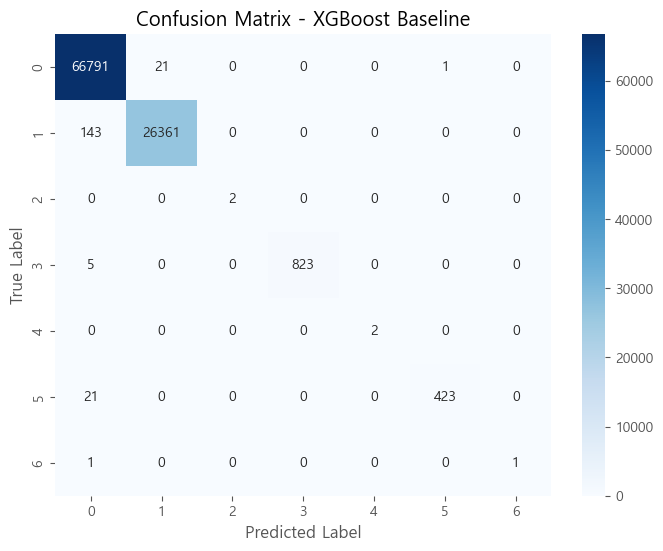

In [56]:
# 혼동 행렬을 계산합니다. labels로 라벨 순서를 0~6으로 고정합니다.
# 라벨을 고정하면 예측이 한 번도 안 된 level이 있어도 축에서 빠지지 않아,
# 희귀 level을 모델이 얼마나 못 맞히는지 그대로 확인할 수 있습니다.
labels_sorted = sorted(train["level"].unique())
cm = confusion_matrix(y_valid, valid_pred, labels=labels_sorted)

# 행(y축)=실제 정답, 열(x축)=모델 예측. 대각선이 진할수록 잘 맞힌 것입니다.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()